In [1]:
import os

import scanpy as sc
import torch

import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import numpy as np
import itertools
from scipy.spatial.distance import cdist

import sys
sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io
from scLEMBAS import latent_separation as ls

/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/tqdm_joblib/__init__.py:4: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/us

In [2]:
n_cores = 30
os.environ["OMP_NUM_THREADS"] = str(1)
os.environ["MKL_NUM_THREADS"] = str(1)
os.environ["OPENBLAS_NUM_THREADS"] = str(1)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(1)
os.environ["NUMEXPR_NUM_THREADS"] = str(1)

seed = 888
mod_seed = 888
data_path = '/home/hmbaghda/orcd/pool/scLEMBAS/analysis'
author = 'McCauley'

device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
n_perts = 3
n_cell_types = 2

In [4]:
tf_adata_og = io.read_tfad(os.path.join(data_path, 'processed', author + '_consensus_tf_activity.h5ad'))
cat_col = 'cell_type'
pert_col = 'ligand'
ctrl_pert = 'CTRL'
covariates = [cat_col, pert_col, 'condition', 'assigned_donor', 'phase']
comparison_metric = 'chance_adjusted_accuracy'

csw = {
    'max_components': 25 ,
    'metric': 'accuracy', 
    'method': 'elbow', 
    'n_folds': 5, 
    'seed': 888
}

assessment_kwargs = {
    'n_perm': 100, 
    'get_q2_pval': True, 
    'get_r2_pval': False, 
    'get_accuracy_pval': False,
    'n_folds': 5, 
    'seed': 888
}


# Round 1: Initial Quantification

In [5]:
tf_adata_round1, _, cv_df_pls_global_round1 = ls.pls_da_pipeline(
    adata = tf_adata_og, 
    pert_ids = tf_adata_og.obs[pert_col].unique().tolist(),
    cat_ids = tf_adata_og.obs[cat_col].unique().tolist(),
    n_components = None,
    control_confounders = None, 
    assess_pls_fit = True,
    pert_col = pert_col,
    cat_col = cat_col,
    separate_by = 'perturbation',
    pls_kwargs = None, 
    component_selection_kwargs = csw,
    assessment_kwargs = assessment_kwargs,
    covariate_associations = covariates,
    per_component_association = False, 
    global_component_association = True,
    run_umap = True,
    file_prefix = None,
    verbose = True,
    n_cores = n_cores,
    seed = seed
)
pls_model = tf_adata_round1.uns['pls']['pls_mod']

Fit PLS Model
Iterate through components for PLS selection of number of components


100%|███████████████████████████████████████████████████████████████████████████████████| 25/25 [03:49<00:00,  9.20s/it]


Begin assessment of final model fit


  0%|                                                                                           | 0/100 [00:00<?, ?it/s]/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33:

/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__versio


100%|█████████████████████████████████████████████████████████████████████████████████| 100/100 [08:47<00:00,  5.27s/it]


Calculate covariate - PLS associations
cell_type
ligand
condition
assigned_donor
phase
cell_type
ligand
condition
assigned_donor
phase
Get UMAP


PLS Assessment Permutations:   0%|                                                              | 0/100 [10:03<?, ?it/s]


In [6]:
tf_adata_round1, _, cv_df_pca_global_round1 = ls.pc_pipeline(
    adata = tf_adata_round1, 
    pert_ids = tf_adata_round1.obs[pert_col].unique().tolist(),
    cat_ids = tf_adata_round1.obs[cat_col].unique().tolist(),
    n_components = None, 
    pert_col = pert_col,
    cat_col = cat_col,
    get_hvgs = False, 
    run_umap = True, 
    covariate_associations = covariates, 
    per_component_association = False, 
    global_component_association = True,
    file_prefix = None, 
    verbose = True,
    n_cores = n_cores, 
    seed = seed
)

Run dimensionality reductions


/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:245: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  Version(ad.__version__) < Version("0.9")
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/neighbors/__init__.py:430: FutureWarning: Use obsm (e.g. `k in adata.obsm` or `adata.obsm.keys() | {'u'}`) instead of AnnData.obsm_keys, AnnData.obsm_keys is deprecated and will be removed in the future.
  if "X_diffmap" in adata.obsm_keys():
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/hmbaghda/Projects/scLEMBAS/scLEMBAS/latent_separation.py:319: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please p

Calculate covariate - PC associations
cell_type
ligand


/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import

condition


...

assigned_donor


/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import

phase


/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import

cell_type
ligand
condition
assigned_donor
phase


Elbow selection via accuracy identified 12 as the optimal number of PLS components
The model fit has a R2Y of 0.21
The model fit has a Q2Y of 0.21, with p-value 0.010
The model fit has a accuracy of 0.44


''

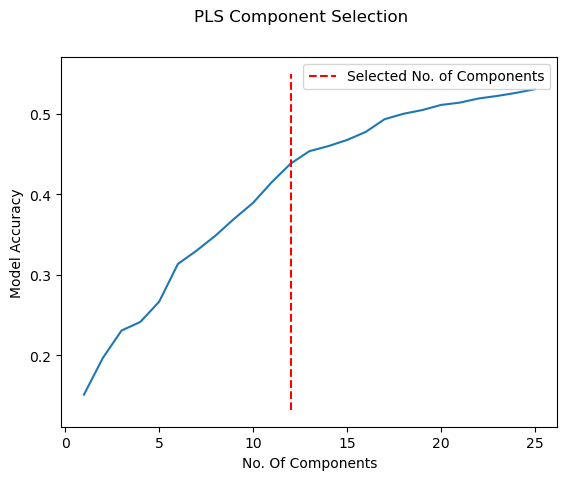

In [7]:
print('Elbow selection via accuracy identified {} as the optimal number of PLS components'.format(pls_model.n_components))
      
for metric_type, metric_vals in pls_model.assessment_metrics.items():
    if metric_type != 'R2X':
        if metric_vals['pval'] is None:
            print('The model fit has a {} of {:.2f}'.format(
                metric_type, metric_vals['value']
            ))
        else:
            print('The model fit has a {} of {:.2f}, with p-value {:.3f}'.format(
                metric_type, metric_vals['value'], metric_vals['pval']
            ))
            
fig, ax = plt.subplots()
sns.lineplot(y = pls_model.metric_per_component, x = range(1, len(pls_model.metric_per_component) + 1), ax = ax)
ymin, ymax = ax.get_ylim()
ax.vlines(x = pls_model.n_components, ymin = ymin, ymax = ymax, label = 'Selected No. of Components',
          color = 'red', linestyle = '--'
         )
ax.set_xlabel('No. Of Components')
ax.set_ylabel('Model Accuracy')
ax.legend()
fig.suptitle('PLS Component Selection')
;

''

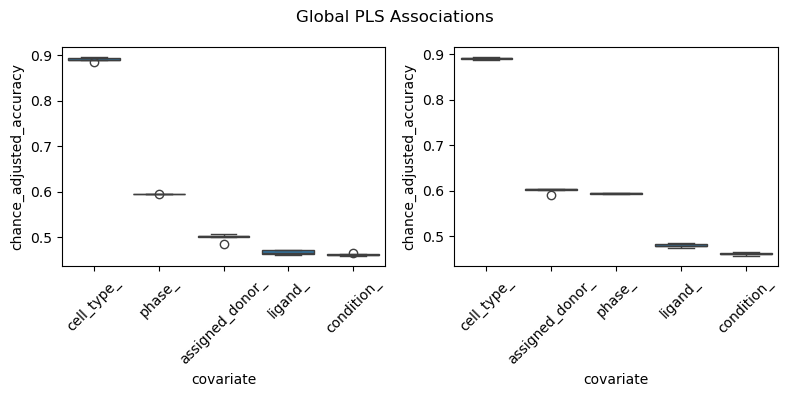

In [8]:
cv_global = cv_df_pls_global_round1.copy()

fig, ax = plt.subplots(ncols = 2, figsize = (8, 4))
for i, model_type in enumerate(cv_global.model_type.unique()):
    viz_df = cv_global[cv_global.model_type == model_type]
    viz_df = viz_df[['fold', 'model_type'] + [col for col in viz_df.columns if col.endswith(comparison_metric)]]
    viz_df.columns = [col if not col.endswith(comparison_metric) else col.split(comparison_metric)[0] for col in viz_df.columns]
    viz_df = viz_df.drop(columns = ['model_type']).melt(id_vars = 'fold', var_name = 'covariate', value_name = 'score')
    x_order = viz_df.groupby('covariate')['score'].median().sort_values(ascending = False).index.tolist()
    viz_df.covariate = pd.Categorical(viz_df.covariate, ordered = True, categories = x_order)
    
    sns.boxplot(data = viz_df, x = 'covariate', y = 'score', ax = ax[i])
    for label in ax[i].get_xticklabels():
        label.set_rotation(45)
    ax[i].set_ylabel(comparison_metric)
    
fig.suptitle('Global PLS Associations')
fig.tight_layout()
;

''

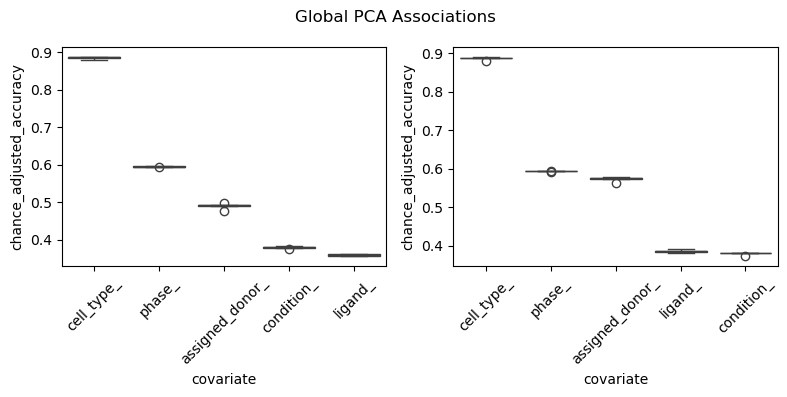

In [24]:
cv_global = cv_df_pca_global_round1.copy()

fig, ax = plt.subplots(ncols = 2, figsize = (8, 4))
for i, model_type in enumerate(cv_global.model_type.unique()):
    viz_df = cv_global[cv_global.model_type == model_type]
    viz_df = viz_df[['fold', 'model_type'] + [col for col in viz_df.columns if col.endswith(comparison_metric)]]
    viz_df.columns = [col if not col.endswith(comparison_metric) else col.split(comparison_metric)[0] for col in viz_df.columns]
    viz_df = viz_df.drop(columns = ['model_type']).melt(id_vars = 'fold', var_name = 'covariate', value_name = 'score')
    x_order = viz_df.groupby('covariate')['score'].median().sort_values(ascending = False).index.tolist()
    viz_df.covariate = pd.Categorical(viz_df.covariate, ordered = True, categories = x_order)
    
    sns.boxplot(data = viz_df, x = 'covariate', y = 'score', ax = ax[i])
    for label in ax[i].get_xticklabels():
        label.set_rotation(45)
    ax[i].set_ylabel(comparison_metric)
    
fig.suptitle('Global PCA Associations')
fig.tight_layout()
;

It looks like in both PLS and PCA space, ligand variance > cell type variance. 

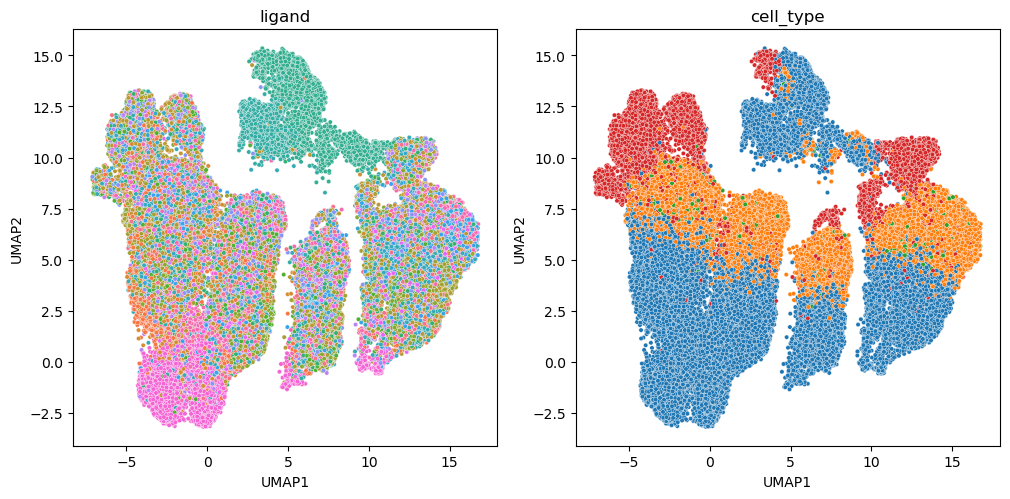

In [10]:
ls.visualize_latent_space(
    adata = tf_adata_round1, 
    latent_label = 'umap', 
    covariates = [pert_col, cat_col], 
    plot_type = 'scatter', 
    components = [1,2], 
    n_frac = 1, 
    legend = False, 
    seed = seed, 
    show_fig = True
)

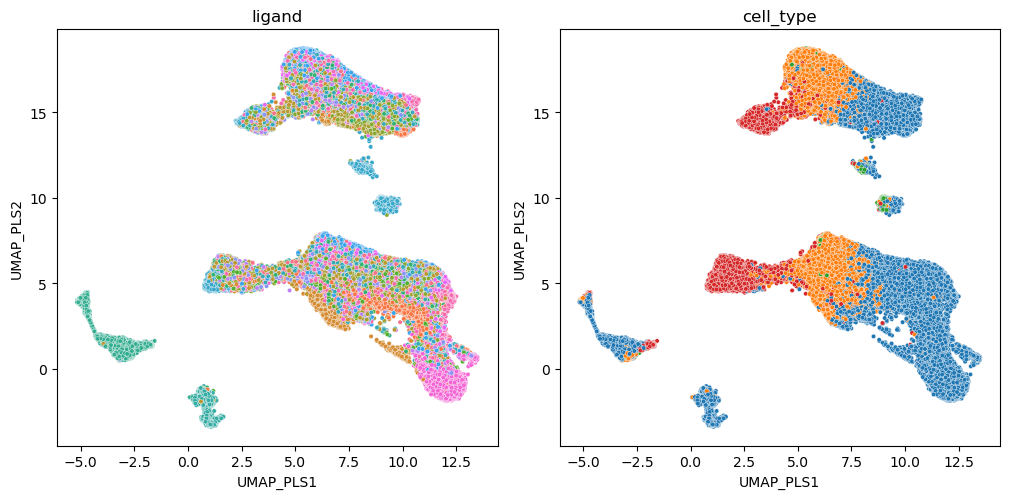

In [11]:
ls.visualize_latent_space(
    adata = tf_adata_round1, 
    latent_label = 'umap_pls', 
    covariates = [pert_col, cat_col], 
    plot_type = 'scatter', 
    components = [1,2], 
    n_frac = 1, 
    legend = False, 
    seed = seed, 
    show_fig = True
)

# Round 2: Filtering Perturbations / Cell Types

1. We choose the top_n perturbations by average euclidean distance separation across all cell types
2. We choose the top_n cell types by highes signal ratio (within to across perturbation distance). 



In [110]:
def compute_pairwise_pert_strength(
    adata,
    latent_label: str,
    cat_col: str,
    pert_col: str,
    min_cells: int = 20,           # ignore perturbations with too few cells
    metric: str = "euclidean",
):
    Z = adata.obsm["X_{}".format(latent_label)]
    meta = adata.obs[[cat_col, pert_col]].copy().reset_index(drop=True)

    Z_df = pd.DataFrame(Z)
    Z_df[cat_col] = meta[cat_col].values
    Z_df[pert_col] = meta[pert_col].values

    feature_cols = Z_df.columns[:-2]

    all_strength_records = []

    # ---- For each cell type, compute centroid distances ----
    for ct, df_ct in Z_df.groupby(cat_col, observed = False):

        # centroids per perturbation within this cell type
        centroids = (
            df_ct.groupby(pert_col, observed = False)[feature_cols]
            .mean()
        )

        # ensure enough cells for reliability
        sizes = df_ct.groupby(pert_col, observed = False).size()
        valid_perts = sizes[sizes >= min_cells].index
        centroids = centroids.loc[valid_perts]

        if centroids.shape[0] < 2:
            continue

        pert_list = centroids.index.tolist()

        # pairwise distances
        dmat = cdist(centroids.values, centroids.values, metric=metric)
        df_d = pd.DataFrame(dmat, index=pert_list, columns=pert_list)

        # per-pert mean distance to all others
        for p in pert_list:
            row = df_d.loc[p, :].drop(p)   # exclude self
            all_strength_records.append({
                "cell_type": ct,
                "perturbation": p,
                "mean_distance_to_others": row.median(),
                "n_perts_in_ct": len(pert_list)
            })


    strength_df = pd.DataFrame(all_strength_records)

    # ---- Aggregate across cell types ----
    pert_strength = (
        strength_df
        .groupby("perturbation", observed = False)["mean_distance_to_others"]
        .mean()
        .sort_values(ascending=False)
        .reset_index()
        .rename(columns={"mean_distance_to_others": "global_mean_sep"})
    )

    return pert_strength, strength_df


def compute_celltype_perturbation_signal(
    adata,
    latent_label: str,
    cat_col: str,
    pert_col: str,
    metric: str = 'euclidean', 
    min_pert_frac = 0.5, 
):
    Z = adata.obsm['X_{}'.format(latent_label)]
    meta = adata.obs[[cat_col, pert_col]].copy()
    meta = meta.reset_index(drop=True)

    Z_df = pd.DataFrame(Z)
    Z_df[cat_col] = meta[cat_col].values
    Z_df[pert_col] = meta[pert_col].values

    feature_cols = Z_df.columns[:-2]
    tot_pert = adata.obs[pert_col].nunique()
    min_pert = max(2, int(np.round(min_pert_frac*tot_pert)))

    stats = []
    for ct, df_ct in Z_df.groupby(cat_col, observed = False):
        # centroids per perturbation within this cell type
        centroids = (
            df_ct.groupby(pert_col, observed = False)[feature_cols]
                .mean()
        )
        centroids.dropna(how = 'all', inplace = True)


        if centroids.shape[0] < min_pert:
            stats.append({
                        cat_col: ct,
                        'aggr_between_pert': np.nan,
                        'aggr_within_pert': np.nan,
                        'signal_ratio': np.nan,
                        'n_cells': df_ct.shape[0],
                        'n_perts': centroids.shape[0],
                    })
            continue  

        # between-perturbation distances
        dmat = cdist(centroids.values, centroids.values, metric=metric)
        tri_inds = np.triu_indices_from(dmat, k=1)
        between = dmat[tri_inds]
        aggr_between = np.median(between)

        # within-perturbation scatter
        within_dists = []
        for pert, df_pert in df_ct.groupby(pert_col, observed = False):
            if pert in centroids.index.tolist():
                c_vec = centroids.loc[pert].values[None, :]
                d = cdist(df_pert[feature_cols].values, c_vec, metric=metric)
                within_dists.extend(d.flatten())
        aggr_within = np.median(within_dists) if len(within_dists) > 0 else np.nan

        signal_ratio = aggr_between / aggr_within if aggr_within > 0 else np.nan

        stats.append({
            cat_col: ct,
            'aggr_between_pert': aggr_between,
            'aggr_within_pert': aggr_within,
            'signal_ratio': signal_ratio,
            'n_cells': df_ct.shape[0],
            'n_perts': centroids.shape[0],
        })

    sort_cols = ['signal_ratio', 'aggr_between_pert', 'aggr_within_pert', 'n_cells']
    sort_asc = [False, False, True, False]
    stats_df = pd.DataFrame(stats).sort_values(sort_cols, ascending=sort_asc)
    return stats_df




## Perturbation Filtering

In [28]:
pert_strength, _ = compute_pairwise_pert_strength(
    adata = tf_adata_round1, 
    latent_label = 'pls', 
    cat_col = cat_col, 
    pert_col = pert_col, 
    min_cells = 20, 
    metric = 'euclidean'
)

pert_strength

,perturbation,global_mean_sep
0,IFNG,10.354711
1,IFNA2,9.668412
2,TGFB1,8.098754
3,IL13,8.030901
4,BMP4,6.727531
5,CHIR99021,6.336580
6,OSM,5.217074
7,IL17A,5.027493
8,TNFA,4.366687
9,LEP,4.183117


In [61]:
n_perts = 5

In [104]:
top_perts = [p for p in pert_strength.perturbation if p!=ctrl_pert][:n_perts]
top_perts.append(ctrl_pert)
print(top_perts)

tf_adata_round2 = tf_adata_og.copy()
tf_adata_round2 = tf_adata_round2[tf_adata_round2.obs[pert_col].isin(top_perts)]

tf_adata_round2.obs.groupby([cat_col, pert_col], observed = False).size().unstack(fill_value=0)


['IFNG', 'IFNA2', 'TGFB1', 'IL13', 'BMP4', 'CTRL']


ligand,BMP4,CTRL,IFNA2,IFNG,IL13,TGFB1
cell_type,,,,,,
Basal,2294,2597,3179,2206,1114,5448
Club,858,2367,525,43,187,96
Goblet,0,40,57,0,726,0
Multiciliated,555,2072,596,0,1184,70


## Cell Type Filtering

In [112]:
ct_dist = compute_celltype_perturbation_signal(
    adata = tf_adata_round2, 
    latent_label = 'pca', 
    cat_col = cat_col, 
    pert_col = pert_col, 
    metric = 'euclidean',
    min_pert_frac = 0.3, 
)

ct_dist

,cell_type,aggr_between_pert,aggr_within_pert,signal_ratio,n_cells,n_perts
0,Basal,7.017361,6.466553,1.085178,16838,6
2,Goblet,5.533758,6.761960,0.818366,823,3
1,Club,5.275784,6.669273,0.791058,4076,6
3,Multiciliated,3.839916,7.244529,0.530044,4477,5


In [113]:
top_cts = ['Basal', 'Club', 'Goblet']
tf_adata_round2 = tf_adata_round2[tf_adata_round2.obs[cat_col].isin(top_cts)].copy()

tf_adata_round2

AnnData object with n_obs × n_vars = 21737 × 380
    obs: 'donor_ID', 'ligand', 'experiment', 'seq_method', 'n_counts', 'mito_frac', 'assigned_donor', 'assigned_donor_id', 'collection_day', 'barcode', 'sample', 'cell_type', 'secretory_mcc_subsets', 'condition', 'S_score', 'G2M_score', 'phase', 'TF_clusters'
    uns: 'leiden', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

## Latent Space Re-Assessment on Cell Type/Pert Subsets

In [114]:
# assessment_kwargs = {'n_perm': None,
#  'get_q2_pval': True,
#  'get_r2_pval': False,
#  'get_accuracy_pval': False,
#  'n_folds': 5,
#  'seed': 888}

In [116]:
tf_adata_round2, _, cv_df_pls_global_round2 = ls.pls_da_pipeline(
    adata = tf_adata_og, 
    pert_ids = top_perts,
    cat_ids = top_cts,
    n_components = None,
    control_confounders = None, 
    assess_pls_fit = True,
    pert_col = pert_col,
    cat_col = cat_col,
    separate_by = 'perturbation',
    pls_kwargs = None, 
    component_selection_kwargs = csw,
    assessment_kwargs = assessment_kwargs,
    covariate_associations = covariates,
    per_component_association = False, 
    global_component_association = True,
    run_umap = True,
    file_prefix = None,
    verbose = True,
    n_cores = n_cores,
    seed = seed
)
pls_model = tf_adata_round2.uns['pls']['pls_mod']


In [117]:
tf_adata_round2, _, cv_df_pca_global_round2 = ls.pc_pipeline(
    adata = tf_adata_round2, 
    pert_ids = tf_adata_round2.obs[pert_col].unique().tolist(),
    cat_ids = tf_adata_round2.obs[cat_col].unique().tolist(),
    n_components = None, 
    pert_col = pert_col,
    cat_col = cat_col,
    get_hvgs = False, 
    run_umap = True, 
    covariate_associations = covariates, 
    per_component_association = False, 
    global_component_association = True,
    file_prefix = None, 
    verbose = True,
    n_cores = n_cores, 
    seed = seed
)

Run dimensionality reductions


/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:245: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  Version(ad.__version__) < Version("0.9")
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/neighbors/__init__.py:430: FutureWarning: Use obsm (e.g. `k in adata.obsm` or `adata.obsm.keys() | {'u'}`) instead of AnnData.obsm_keys, AnnData.obsm_keys is deprecated and will be removed in the future.
  if "X_diffmap" in adata.obsm_keys():
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Calculate covariate - PC associations
cell_type


/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import

ligand
condition
assigned_donor
phase
cell_type
ligand
condition
assigned_donor
phase


Elbow selection via accuracy identified 5 as the optimal number of PLS components
The model fit has a R2Y of 0.65
The model fit has a Q2Y of 0.66
The model fit has a accuracy of 0.90


''

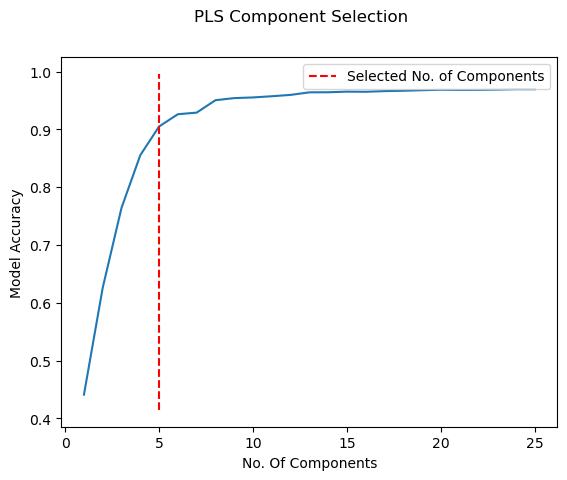

In [118]:
print('Elbow selection via accuracy identified {} as the optimal number of PLS components'.format(pls_model.n_components))
      
for metric_type, metric_vals in pls_model.assessment_metrics.items():
    if metric_type != 'R2X':
        if metric_vals['pval'] is None:
            print('The model fit has a {} of {:.2f}'.format(
                metric_type, metric_vals['value']
            ))
        else:
            print('The model fit has a {} of {:.2f}, with p-value {:.3f}'.format(
                metric_type, metric_vals['value'], metric_vals['pval']
            ))
            
fig, ax = plt.subplots()
sns.lineplot(y = pls_model.metric_per_component, x = range(1, len(pls_model.metric_per_component) + 1), ax = ax)
ymin, ymax = ax.get_ylim()
ax.vlines(x = pls_model.n_components, ymin = ymin, ymax = ymax, label = 'Selected No. of Components',
          color = 'red', linestyle = '--'
         )
ax.set_xlabel('No. Of Components')
ax.set_ylabel('Model Accuracy')
ax.legend()
fig.suptitle('PLS Component Selection')
;



''

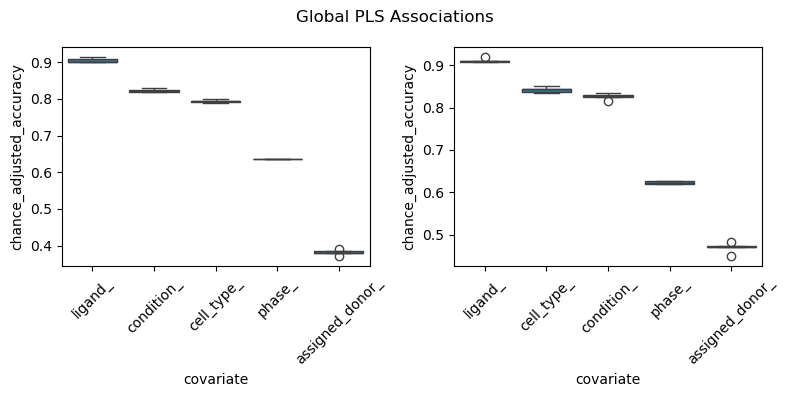

In [119]:
cv_global = cv_df_pls_global_round2.copy()

fig, ax = plt.subplots(ncols = 2, figsize = (8, 4))
for i, model_type in enumerate(cv_global.model_type.unique()):
    viz_df = cv_global[cv_global.model_type == model_type]
    viz_df = viz_df[['fold', 'model_type'] + [col for col in viz_df.columns if col.endswith(comparison_metric)]]
    viz_df.columns = [col if not col.endswith(comparison_metric) else col.split(comparison_metric)[0] for col in viz_df.columns]
    viz_df = viz_df.drop(columns = ['model_type']).melt(id_vars = 'fold', var_name = 'covariate', value_name = 'score')
    x_order = viz_df.groupby('covariate')['score'].median().sort_values(ascending = False).index.tolist()
    viz_df.covariate = pd.Categorical(viz_df.covariate, ordered = True, categories = x_order)
    
    sns.boxplot(data = viz_df, x = 'covariate', y = 'score', ax = ax[i])
    for label in ax[i].get_xticklabels():
        label.set_rotation(45)
    ax[i].set_ylabel(comparison_metric)
    
fig.suptitle('Global PLS Associations')
fig.tight_layout()
;

''

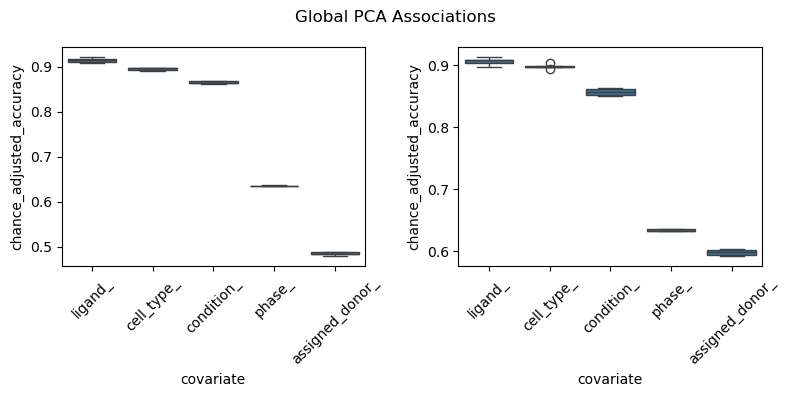

In [120]:
cv_global = cv_df_pca_global_round2.copy()

fig, ax = plt.subplots(ncols = 2, figsize = (8, 4))
for i, model_type in enumerate(cv_global.model_type.unique()):
    viz_df = cv_global[cv_global.model_type == model_type]
    viz_df = viz_df[['fold', 'model_type'] + [col for col in viz_df.columns if col.endswith(comparison_metric)]]
    viz_df.columns = [col if not col.endswith(comparison_metric) else col.split(comparison_metric)[0] for col in viz_df.columns]
    viz_df = viz_df.drop(columns = ['model_type']).melt(id_vars = 'fold', var_name = 'covariate', value_name = 'score')
    x_order = viz_df.groupby('covariate')['score'].median().sort_values(ascending = False).index.tolist()
    viz_df.covariate = pd.Categorical(viz_df.covariate, ordered = True, categories = x_order)
    
    sns.boxplot(data = viz_df, x = 'covariate', y = 'score', ax = ax[i])
    for label in ax[i].get_xticklabels():
        label.set_rotation(45)
    ax[i].set_ylabel(comparison_metric)
    
fig.suptitle('Global PCA Associations')
fig.tight_layout()
;


We can see that now, perturbation is highly distinguishable, and not at the cost of cell type. 

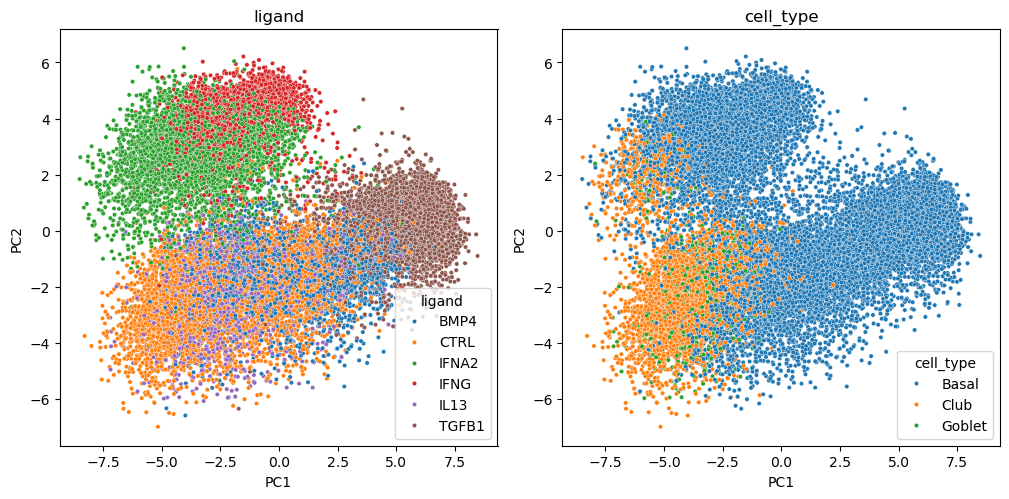

In [121]:
ls.visualize_latent_space(
    adata = tf_adata_round2, 
    latent_label = 'pca', 
    covariates = [pert_col, cat_col], 
    plot_type = 'scatter', 
    components = [1,2], 
    n_frac = 1, 
    legend = True, 
    seed = seed, 
    show_fig = True
)

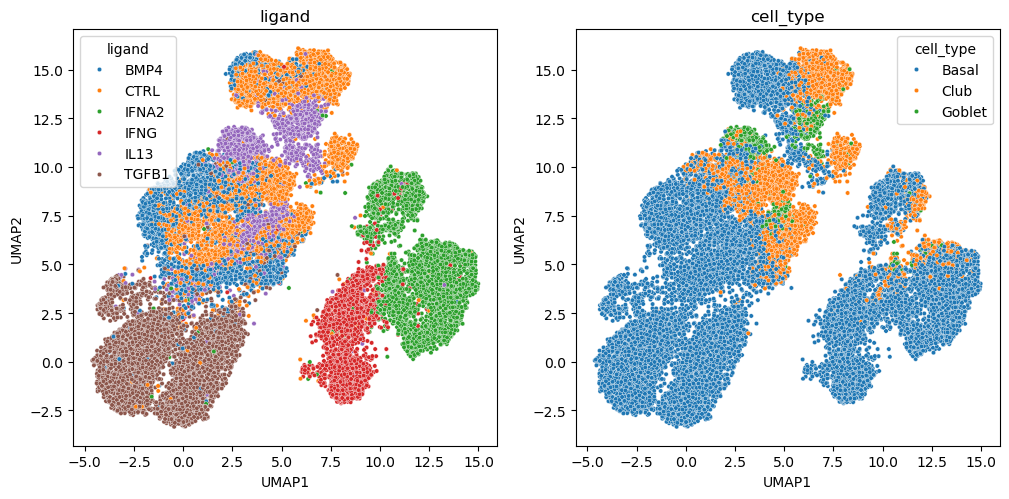

In [122]:
ls.visualize_latent_space(
    adata = tf_adata_round2, 
    latent_label = 'umap', 
    covariates = [pert_col, cat_col], 
    plot_type = 'scatter', 
    components = [1,2], 
    n_frac = 1, 
    legend = True, 
    seed = seed, 
    show_fig = True
)

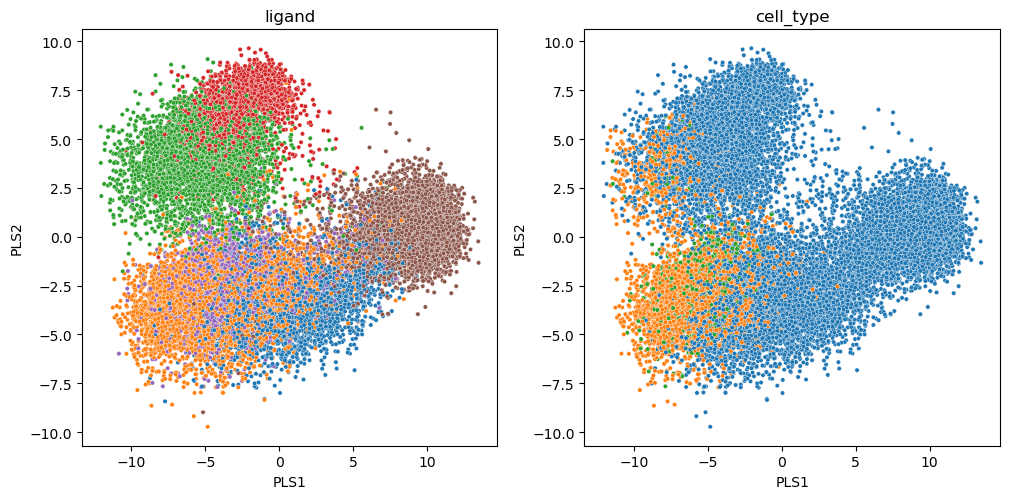

In [124]:
ls.visualize_latent_space(
    adata = tf_adata_round2, 
    latent_label = 'pls', 
    covariates = [pert_col, cat_col], 
    plot_type = 'scatter', 
    components = [1,2],  
    n_frac = 1, 
    legend = False, 
    seed = seed, 
    show_fig = True
)

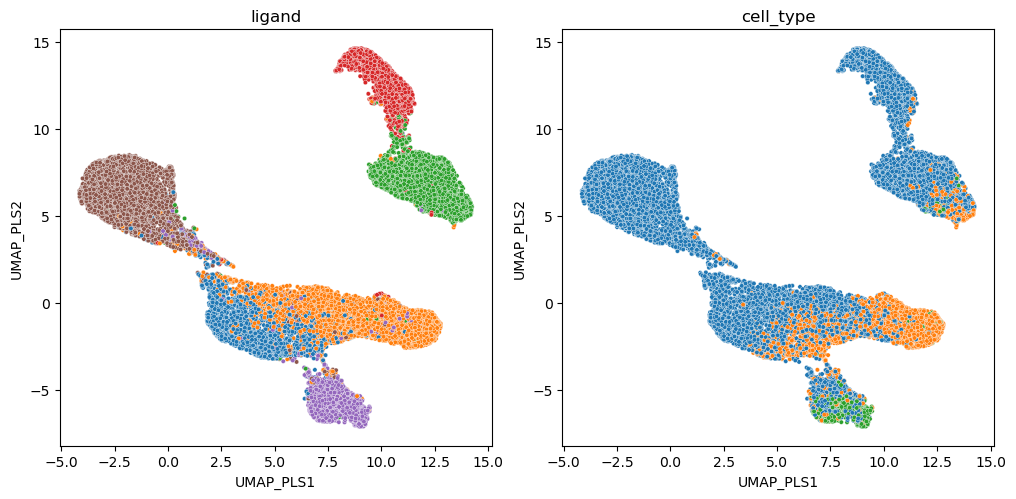

In [123]:
ls.visualize_latent_space(
    adata = tf_adata_round2, 
    latent_label = 'umap_pls', 
    covariates = [pert_col, cat_col], 
    plot_type = 'scatter', 
    components = [1,2],  
    n_frac = 1, 
    legend = False, 
    seed = seed, 
    show_fig = True
)

# Signaling Network

Let's reprocess the signaling network according to the new set of ligands. We copy this directly from the 02 script

In [136]:
from scLEMBAS import parse_network as pn

In [137]:
source_label = 'source_genesymbol'
target_label = 'target_genesymbol'
weight_label = 'mode_of_action'
stimulation_label = 'consensus_stimulation'
inhibition_label = 'consensus_inhibition'

sn_ppis = pn.load_network('omnipath', organism = 'human', static = True)
sn_ppis = pn.correct_network(sn_ppis = sn_ppis,
                                        source_label = source_label, target_label = target_label,
                                        stimulation_label = stimulation_label, inhibition_label = inhibition_label)


moa_map = {
    'CHIR99021': {'GSK3A': -1, 'GSK3B': -1, 'CDK1': -1, 'MAPK1': -1}, 
    'TNFA': {'TNFRSF1A': 1, 'TNFRSF1B': 1}
}

# format as input to parsing network
delim = '&'
interactions_to_add = []
moa = []
for source, targets in moa_map.items():
    for target, moa_ in targets.items():
        interactions_to_add.append(delim.join([source, target]))
        moa.append(moa_)
        
        
# add to network
sn_ppis = pn.add_omnipath_interaction(sn_ppis = sn_ppis,
                                      interactions_to_add = interactions_to_add,  
                                      moa = moa,
                                      delim = delim,
                                      source_label = source_label,
                                      target_label = target_label, 
                                      stimulation_label = stimulation_label, 
                                      inhibition_label = inhibition_label
                           )

sn_ppis = pn.extract_network(sn_ppis = sn_ppis.copy(), 
                             curation_effort_thresh = 2, 
                             n_references_thresh = 1,
                             resources = 'all', 
                             drop_self = True, 
                             source_label = source_label, 
                             target_label = target_label,
                             verbose = True)

ligand_labels = sorted(set(tf_adata_round2.obs[pert_col]).difference([ctrl_pert]))
tf_labels = tf_adata_round2.var.index.unique().tolist()

ppi_nodes = set(sn_ppis[source_label].tolist() + sn_ppis[target_label].tolist())
n_tf_intersect_ = len(ppi_nodes.intersection(tf_labels))
print('{} of {} TFs are present in Omnipath upon applying signaling network thresholds'.format(n_tf_intersect_, 
                                                                          tf_adata_round2.shape[1], 
                                                                         ))


n_og = sn_ppis.shape[0]
sn_ppis, ligand_connections = pn.create_connected_network(sn_ppis = sn_ppis, 
                                                       ligand_labels = ligand_labels, 
                                                       tf_labels = tf_labels, 
                                                       source_label = source_label, 
                                                       target_label = target_label,
                                                       path_finder = 'connected')


assert all([len(v) > 0 for k,v in ligand_connections.items()]), 'A ligand was excluded from the connected paths'

all_nodes_ = sorted(set(sn_ppis[source_label].tolist() + sn_ppis[target_label].tolist()))
print('Connected paths filtered the network from {} to {} interactions, leaving a total of {} nodes'.format(n_og, sn_ppis.shape[0], len(all_nodes_)))
# print('{} of {} TFs are retained in the final signaling network'.format(len(ligand_connections['IFNB1']), 
#                                                                         len(tf_labels)))
ppi_nodes = set(sn_ppis[source_label].tolist() + sn_ppis[target_label].tolist())
n_tf_intersect = len(ppi_nodes.intersection(tf_labels))
print('{} of {} TFs are present in upon filtering for connected paths'.format(n_tf_intersect, 
                                                                          n_tf_intersect_, 
                                                                         ))

sn_ppis = pn.format_network(sn_ppis, weight_label, stimulation_label, inhibition_label) 

sn_ppis.to_csv(os.path.join(data_path, 'trash', author + 'sepsubset_sn_ppis.csv'))

/home/hmbaghda/Projects/scLEMBAS/scLEMBAS/parse_network.py:162: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  unique_vals = pd.concat([unique_vals, dup_int], axis = 0)


The thresholds filtered 107345  of 133613 interactions
380 of 380 TFs are present in Omnipath upon applying signaling network thresholds
Connected paths filtered the network from 26266 to 17597 interactions, leaving a total of 2504 nodes
380 of 380 TFs are present in upon filtering for connected paths


Since no additional TFs are filtered, we can proceed with tf_adata_round2.

In [138]:
del tf_adata_round2.obs["TF_clusters"]

for col in [cat_col, pert_col, 'condition']:
    tf_adata_round2.obs[col] = tf_adata_round2.obs[col].cat.remove_unused_categories()
    
io.write_tfad(tf_adata_round2, 
             os.path.join(data_path, 'trash', author + 'sepsubset_consensus_tf_activity.h5ad'))